# Installing Dependencies

In [ ]:
!pip install -U timm
!pip install -U albumentations

In [ ]:
import torch
import torch.nn as nn
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import timm
import cv2
import spacy
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import pandas as pd
from collections import Counter
import nltk
from nltk.tokenize import wordpunct_tokenize

In [ ]:
torch.backends.cudnn.benchmark = True
cv2.setNumThreads(0)   # important when using num_workers > 0


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Loading the Dataset

In [ ]:
from google.colab import drive
from google.colab.patches import cv2_imshow

drive.mount('/content/drive')

%cd "drive/MyDrive/Flickr8kVersion"

caption_filename = 'captions.txt'
missing = '2258277193_586949ec62.jpg'

with open(caption_filename) as captions:
    lines = captions.readlines()

get_captions = {}
all_captions = []

for caption in lines:
    data = caption.rstrip('\n').split('.jpg,')
    img_name = data[0] + '.jpg'
    if img_name == missing:
        continue
    caption_list = get_captions.get(img_name, [])
    caption_list.append(data[1])
    get_captions[img_name] = caption_list
    all_captions.append(data[1])

df = pd.DataFrame(columns=['filename','caption'])
df['filename'] = get_captions.keys()
df['caption'] = df['filename'].map(lambda filename: get_captions[filename])
df = df.explode('caption', ignore_index=True)  # each row has one caption string
df = df.reset_index(drop=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: 'drive/MyDrive/Flickr8kVersion'
/content/drive/MyDrive/Flickr8kVersion


# Tokenization

In [ ]:
nltk.download("punkt", quiet=True)

vocab_frequency = Counter()

def word_tokenizer(text):  # mimics torchtext basic_english-ish behavior
    return [t.lower() for t in wordpunct_tokenize(text) if t.isalnum()]

for cap in all_captions:
    vocab_frequency.update(word_tokenizer(cap))

# "vocabulary" replacement (dicts + default index)
vocabulary = {"itos": ["<UNKNOWN>", "<PAD>", "<START>", "<END>"], "stoi": {}}
vocabulary["itos"] += sorted(vocab_frequency.keys(), key=lambda w: (-vocab_frequency[w], w))
vocabulary["stoi"] = {w: i for i, w in enumerate(vocabulary["itos"])}
vocabulary["default_index"] = 0  # same idea as set_default_index(0)

# usage:
# idx = vocabulary["stoi"].get(token, vocabulary["default_index"])
# token = vocabulary["itos"][idx]

# Defining the Model Architecture

In [ ]:
class ImageCaptioner(nn.Module):
    def __init__(self, context_length, vocabulary_size, num_blocks, model_dim, num_heads, prob):
        super().__init__()
        self.cnn_encoder = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='avg')
        test_image = torch.zeros(1, 3, 224, 224)
        with torch.no_grad():
            cnn_output = self.cnn_encoder(test_image)
        in_features = cnn_output.shape[1]
        self.project = nn.Linear(in_features, model_dim)

        self.word_embeddings = nn.Embedding(vocabulary_size, model_dim)
        self.pos_embeddings = nn.Embedding(context_length, model_dim)

        block = nn.TransformerDecoderLayer(model_dim, num_heads, 2*model_dim, dropout=prob, batch_first=True, norm_first=True)
        self.blocks = nn.TransformerDecoder(block, num_blocks)

        self.vocab_projection = nn.Linear(model_dim, vocabulary_size)

    def forward(self, image, true_labels):
        B, T = true_labels.shape
        pad_id = vocabulary["stoi"]["<PAD>"]
        tok_embedded = self.word_embeddings(true_labels)                 # (B,T,D)
        pos = torch.arange(T, device=true_labels.device)                 # (T,)
        pos_embedded = self.pos_embeddings(pos)                          # (T,D)
        total_embeddings = tok_embedded + pos_embedded                   # (B,T,D)

        with torch.no_grad():
            x = self.cnn_encoder(image).view(B, -1)
        encoded_image = self.project(x)
        memory = encoded_image.unsqueeze(1)                              # (B,1,D)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(true_labels.device)
        tgt_key_padding_mask = (true_labels == pad_id)                   # (B,T)

        out = self.blocks(
            total_embeddings,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )

        return self.vocab_projection(out)

# DataSet Class

In [ ]:
class ImageCaptioningDataset(Dataset):
    def __init__(self, split):
        self.df = df
        self.img_size = 224
        transformation_list = [alb.Resize(self.img_size, self.img_size)]
        if split == 'training':
            transformation_list.append(alb.HorizontalFlip())
            transformation_list.append(alb.ColorJitter())
        transformation_list.append(alb.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)))
        transformation_list.append(ToTensorV2())

        self.transformations = alb.Compose(transformation_list)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_filename, cap = self.df.iloc[idx]          # <-- use the caption from the dataframe row
        cap = str(cap).strip()

        actual_image = cv2.cvtColor(cv2.imread('Images/' + image_filename), cv2.COLOR_BGR2RGB)
        transformed_img = self.transformations(image=actual_image)['image']

        tokens = word_tokenizer(cap)
        integers = [vocabulary["stoi"].get(w, vocabulary["default_index"]) for w in tokens]
        integers = [vocabulary["stoi"]["<START>"]] + integers + [vocabulary["stoi"]["<END>"]]

        if len(integers) <= context_length:
            integers += [vocabulary["stoi"]["<PAD>"]] * (context_length - len(integers))
        else:
            integers = integers[:context_length - 1] + [vocabulary["stoi"]["<END>"]]

        return transformed_img, torch.tensor(integers, dtype=torch.long)


# Training

In [ ]:
training_dataset = ImageCaptioningDataset('training')
training_data = DataLoader(
    training_dataset,
    batch_size=128,          # bump if you have VRAM
    shuffle=True,
    num_workers=8,          # try 2, 4, or 8 on Colab
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)


In [ ]:
context_length = 20
V = len(vocabulary['itos']) # vocabulary_size
num_blocks = 6
model_dim = 512
num_heads = 16
prob = 0.1

model = ImageCaptioner(context_length, V, num_blocks, model_dim, num_heads, prob).to(device)

for layer in model.cnn_encoder.parameters():
    layer.requires_grad = False

loss_function = nn.CrossEntropyLoss(ignore_index=vocabulary['stoi']['<PAD>'])
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [ ]:
def decode(ids):
    return " ".join([vocabulary["itos"][i] for i in ids if i < len(vocabulary["itos"])])

for i in [0, 5, 10, 15, 20]:
    _, y = training_dataset[i]
    print(i, decode(y.tolist()))

for i in [0, 5, 10, 15, 20]:
    print(i, training_dataset.df.iloc[i]["filename"])

0 <START> a child in a pink dress is climbing up a set of stairs in an entry way <END> <PAD>
5 <START> a black dog and a spotted dog are fighting <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
10 <START> a little girl covered in paint sits in front of a painted rainbow with her hands in a <END>
15 <START> a man lays on a bench while his dog sits by him <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
20 <START> a man in an orange hat starring at something <END> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>
0 1000268201_693b08cb0e.jpg
5 1001773457_577c3a7d70.jpg
10 1002674143_1b742ab4b8.jpg
15 1003163366_44323f5815.jpg
20 1007129816_e794419615.jpg


In [ ]:
# Training Loop

%%time

num_epochs = 40
num_iterations = 0
log_every = 1

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

for epoch in range(num_epochs):
    model.train()
    # CNN is frozen; keep it in eval mode (saves some overhead / keeps BN stable)
    model.cnn_encoder.eval()

    running_loss = 0.0
    steps = 0

    for images, captions in training_data:
        images = images.to(device, non_blocking=True)
        captions = captions.to(device, non_blocking=True)

        # Shift for next-token prediction:
        #   input:  <START> w1 w2 ... w_{T-2}
        #   target: w1      w2 ... w_{T-2} <END>/<PAD>
        captions_in = captions[:, :-1]   # (B, T-1)
        targets     = captions[:, 1:]    # (B, T-1)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images, captions_in)  # expected (B, T-1, V)
            loss = loss_function(
                logits.reshape(-1, V),      # (B*(T-1), V)
                targets.reshape(-1)         # (B*(T-1),)
            )

        scaler.scale(loss).backward()

        # Important: unscale before clipping when using AMP
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        steps += 1

        if num_iterations % log_every == 0:
            print(f"epoch {epoch+1:02d}/{num_epochs} | iter {num_iterations:06d} | loss {loss.item():.4f}")

        num_iterations += 1

    print(f"epoch {epoch+1:02d} done | avg loss {running_loss / max(steps, 1):.4f}")


<timed exec>:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
<timed exec>:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


epoch 01/40 | iter 000000 | loss 0.7711
epoch 01/40 | iter 000001 | loss 0.7862
epoch 01/40 | iter 000002 | loss 0.7611
epoch 01/40 | iter 000003 | loss 0.8091
epoch 01/40 | iter 000004 | loss 0.8376
epoch 01/40 | iter 000005 | loss 0.7410
epoch 01/40 | iter 000006 | loss 0.7899
epoch 01/40 | iter 000007 | loss 0.7799
epoch 01/40 | iter 000008 | loss 0.7670
epoch 01/40 | iter 000009 | loss 0.7988
epoch 01/40 | iter 000010 | loss 0.7638
epoch 01/40 | iter 000011 | loss 0.7841
epoch 01/40 | iter 000012 | loss 0.7828
epoch 01/40 | iter 000013 | loss 0.7761
epoch 01/40 | iter 000014 | loss 0.7753
epoch 01/40 | iter 000015 | loss 0.7390
epoch 01/40 | iter 000016 | loss 0.7900
epoch 01/40 | iter 000017 | loss 0.7583
epoch 01/40 | iter 000018 | loss 0.7383
epoch 01/40 | iter 000019 | loss 0.7755
epoch 01/40 | iter 000020 | loss 0.7740
epoch 01/40 | iter 000021 | loss 0.8009
epoch 01/40 | iter 000022 | loss 0.7900
epoch 01/40 | iter 000023 | loss 0.7928
epoch 01/40 | iter 000024 | loss 0.8019


KeyboardInterrupt: 

In [ ]:
# Save Trained Model

torch.save(model.state_dict(), 'weights.pt')
# from google.colab import files
# files.download('weights.pt')

# Loading the Model

If you have already trained a model, just comment out the above two coding cells (commented "\# Training Loop" and "\# Save Trained Model") and run all cells

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Flickr8kVersion"
model.load_state_dict(torch.load('weights.pt'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Flickr8kVersion


<All keys matched successfully>

# Generation

In [ ]:
import torch
import torch.nn as nn
import albumentations as alb
from albumentations.pytorch import ToTensorV2
import cv2

def build_inference_transform(img_size=224):
    return alb.Compose([
        alb.Resize(img_size, img_size),
        alb.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),      # ImageNet mean/std by default
        ToTensorV2(),
    ])

@torch.inference_mode()
def generate_caption(
    model,
    image_path: str,
    vocabulary: dict,
    context_length: int,
    device,
    img_size: int = 224,
    max_new_tokens: int | None = None,
    temperature: float = 0.0,      # 0.0 => greedy
    top_k: int | None = None,
):
    """
    model: your ImageCaptioner
    vocabulary: {"itos": [...], "stoi": {...}, "default_index": 0}
    """

    model.eval()
    model.cnn_encoder.eval()

    transform = build_inference_transform(img_size)

    # token ids
    start_id = vocabulary["stoi"]["<START>"]
    end_id   = vocabulary["stoi"]["<END>"]
    pad_id   = vocabulary["stoi"]["<PAD>"]
    unk_id   = vocabulary["stoi"]["<UNKNOWN>"]

    # defaults
    if max_new_tokens is None:
        max_new_tokens = context_length - 1  # because we already include <START>

    # ---- load + preprocess image ----
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    image_tensor = transform(image=img)["image"].unsqueeze(0).to(device)  # (1,3,H,W)

    # ---- encode image ONCE ----
    x = model.cnn_encoder(image_tensor).view(1, -1)  # (1, in_features)
    encoded_image = model.project(x)                 # (1, model_dim)
    memory = encoded_image.unsqueeze(1)              # (1, 1, model_dim)

    # ---- autoregressive decode ----
    token_ids = [start_id]

    for _ in range(max_new_tokens):
        tgt = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, T)
        T = tgt.size(1)

        # embeddings
        tok_emb = model.word_embeddings(tgt)                  # (1, T, D)
        pos = torch.arange(T, device=device)                  # (T,)
        pos_emb = model.pos_embeddings(pos)                   # (T, D)
        tgt_emb = tok_emb + pos_emb                           # broadcast -> (1, T, D)

        # causal mask
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T).to(device)

        # decoder
        dec_out = model.blocks(tgt_emb, memory, tgt_mask=tgt_mask)   # (1, T, D)
        logits = model.vocab_projection(dec_out)                     # (1, T, V)
        next_logits = logits[0, -1, :]                                # (V,)

        # (optional) block some tokens from being generated
        next_logits[pad_id] = -float("inf")
        next_logits[start_id] = -float("inf")

        # greedy vs sampling
        if temperature is None or temperature <= 0:
            next_id = int(torch.argmax(next_logits).item())
        else:
            scaled = next_logits / temperature

            if top_k is not None and top_k > 0:
                k = min(top_k, scaled.numel())
                vals, idxs = torch.topk(scaled, k=k)
                filtered = torch.full_like(scaled, -float("inf"))
                filtered[idxs] = vals
                scaled = filtered

            probs = torch.softmax(scaled, dim=-1)
            next_id = int(torch.multinomial(probs, num_samples=1).item())

        token_ids.append(next_id)

        if next_id == end_id:
            break

        # hard stop at context length
        if len(token_ids) >= context_length:
            break

    # ---- decode ids to text ----
    words = []
    for tid in token_ids[1:]:  # skip <START>
        if tid == end_id:
            break
        if tid == pad_id:
            continue
        if tid < len(vocabulary["itos"]):
            w = vocabulary["itos"][tid]
        else:
            w = vocabulary["itos"][unk_id]
        # optional: skip unknowns if you want cleaner output
        # if w == "<UNKNOWN>": continue
        words.append(w)

    return " ".join(words)


Saving College-St-Cycleway.jpg to College-St-Cycleway.jpg
Uploaded: College-St-Cycleway.jpg


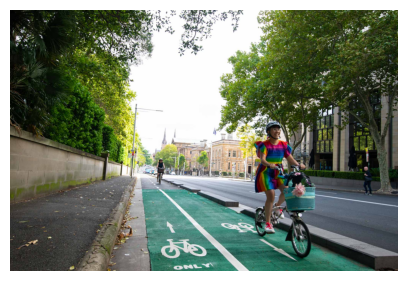


Caption:
 a young boy wearing a red helmet rides his bicycle down a road


In [ ]:
# --- Colab: upload an image + run caption generation ---

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torch

# 1) Upload
uploaded = files.upload()  # choose an image file from your computer
image_path = next(iter(uploaded.keys()))  # get the uploaded filename

print("Uploaded:", image_path)

# 2) Display the image
img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

# 3) Pick device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)   # assumes `model` already exists + has weights loaded

# 4) Generate caption
caption = generate_caption(
    model=model,
    image_path=image_path,
    vocabulary=vocabulary,
    context_length=context_length,
    device=device,
    temperature=0.6,
    top_k=50,
)

print("\nCaption:\n", caption)
